In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/amritachatterjee09/lead-scoring-dataset/Lead Scoring.csv
/kaggle/input/datasets/amritachatterjee09/lead-scoring-dataset/Leads Data Dictionary.xlsx


In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/amritachatterjee09/lead-scoring-dataset/Lead Scoring.csv")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

In [4]:
df = pd.read_csv("/kaggle/input/datasets/amritachatterjee09/lead-scoring-dataset/Lead Scoring.csv")

In [5]:
# Remove ID columns
df.drop(['Prospect ID', 'Lead Number'], axis=1, inplace=True)

# Remove constant columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
df.drop(columns=constant_cols, inplace=True)

# Remove columns having >40% missing values
missing_percent = df.isnull().mean() * 100
drop_cols = missing_percent[missing_percent > 40].index
df.drop(columns=drop_cols, inplace=True)

print(df.shape)

(9240, 25)


In [6]:
print(df['Converted'].value_counts())
print(df['Converted'].value_counts(normalize=True) * 100)

Converted
0    5679
1    3561
Name: count, dtype: int64
Converted
0    61.461039
1    38.538961
Name: proportion, dtype: float64


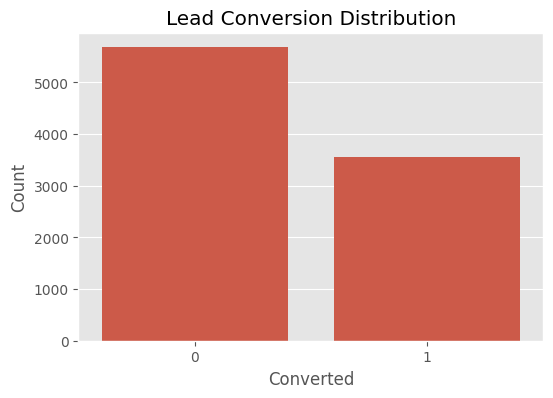

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='Converted', data=df)

plt.title("Lead Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Count")

plt.show()

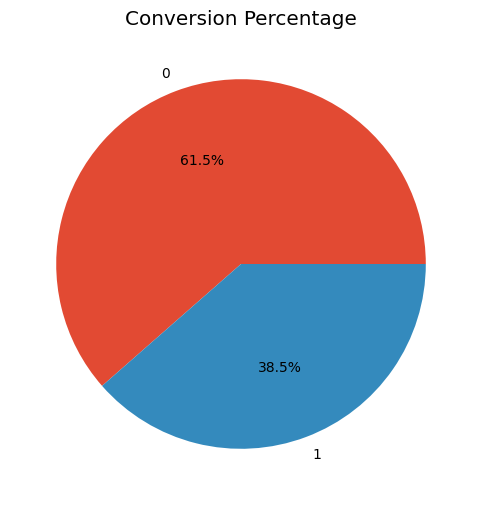

In [8]:
df['Converted'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Conversion Percentage")
plt.show()

In [9]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['Converted', 'TotalVisits', 'Total Time Spent on Website',
       'Page Views Per Visit'],
      dtype='object')


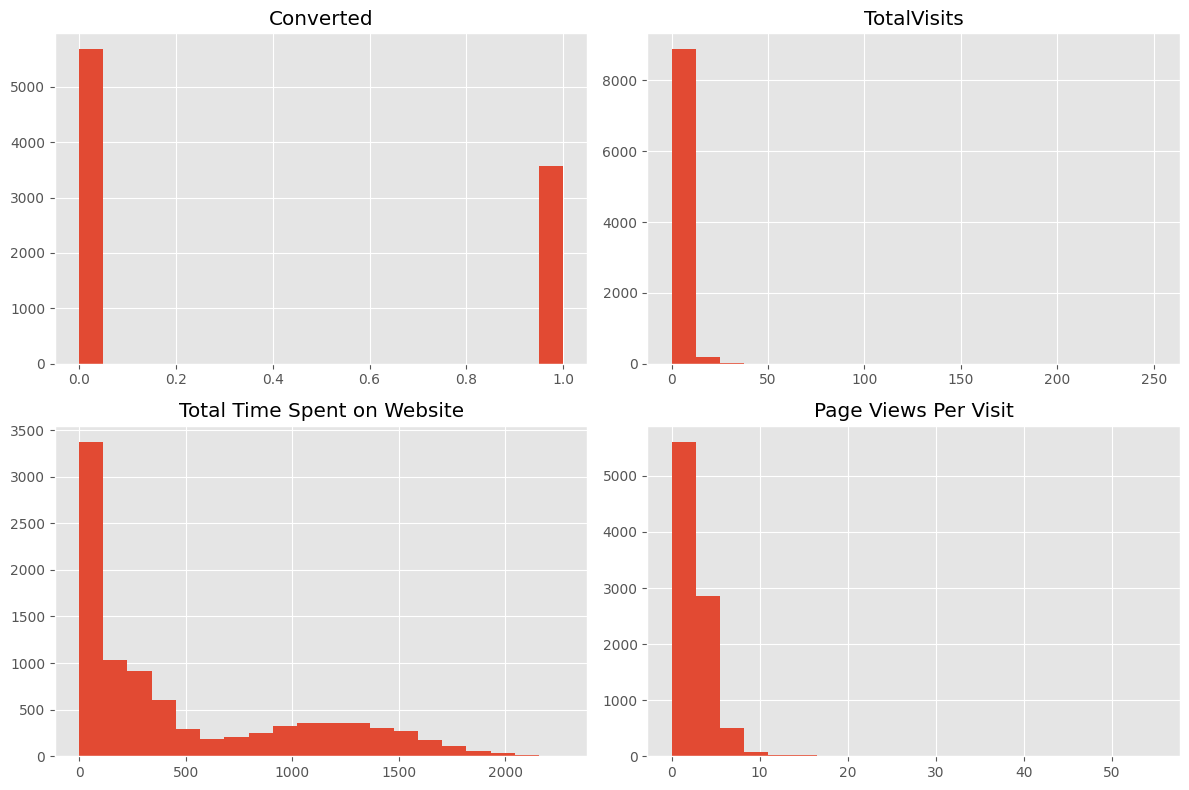

In [10]:
df[num_cols].hist(figsize=(12,8), bins=20)

plt.tight_layout()
plt.show()

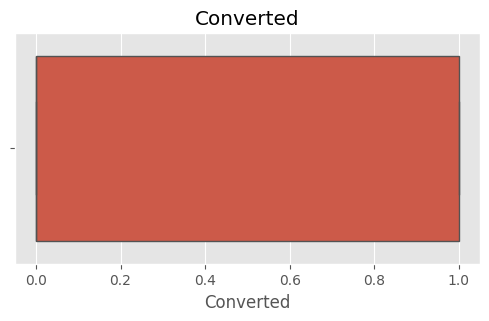

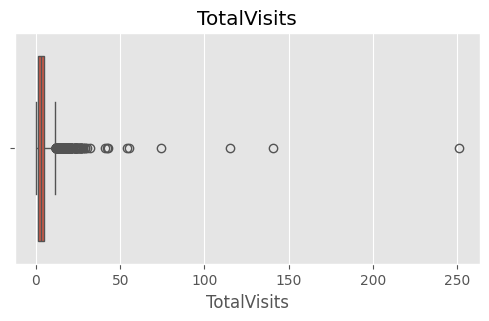

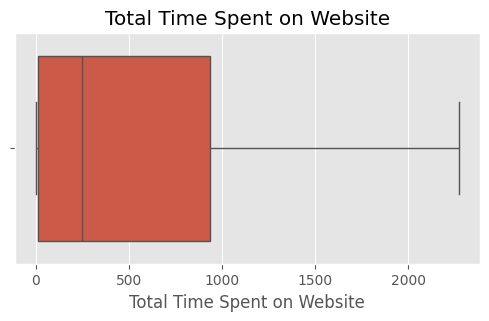

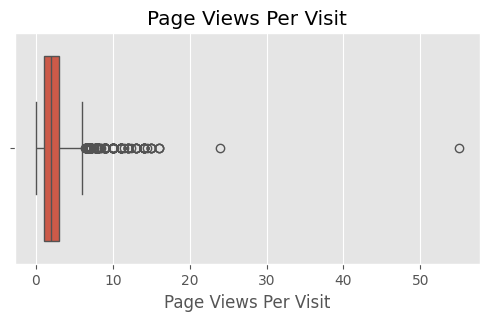

In [11]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

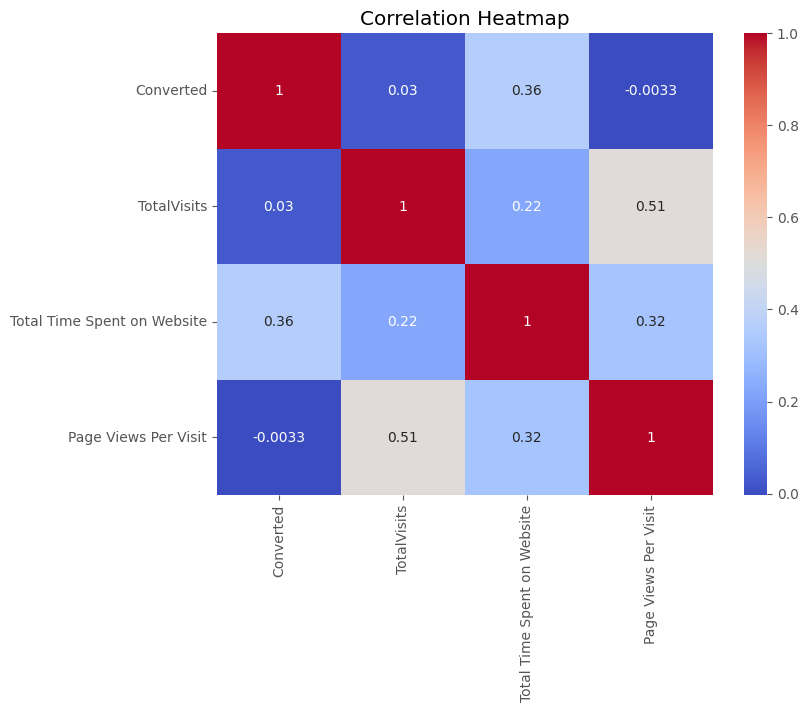

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [13]:
cat_cols = df.select_dtypes(include='object').columns

print("Total Categorical Columns:", len(cat_cols))
print(cat_cols)

Total Categorical Columns: 21
Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call',
       'Last Activity', 'Country', 'Specialization',
       'How did you hear about X Education', 'What is your current occupation',
       'What matters most to you in choosing a course', 'Search',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations', 'Tags',
       'Lead Profile', 'City', 'A free copy of Mastering The Interview',
       'Last Notable Activity'],
      dtype='object')


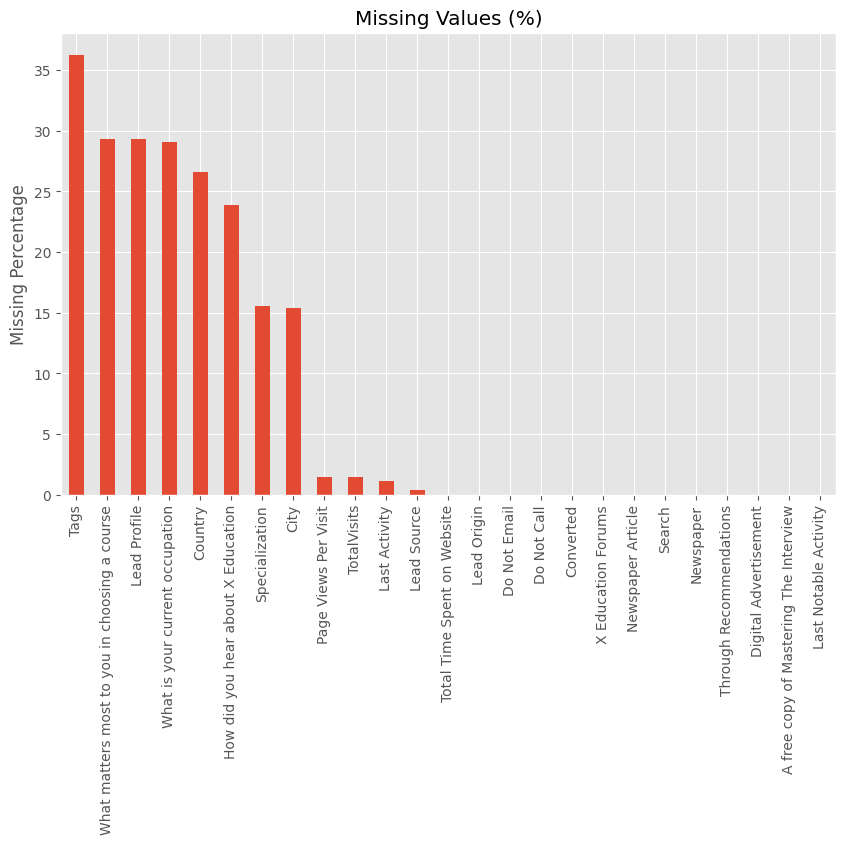

In [14]:
plt.figure(figsize=(10,6))

(df.isnull().sum().sort_values(ascending=False)/len(df)*100).plot(kind='bar')

plt.ylabel("Missing Percentage")
plt.title("Missing Values (%)")
plt.show()

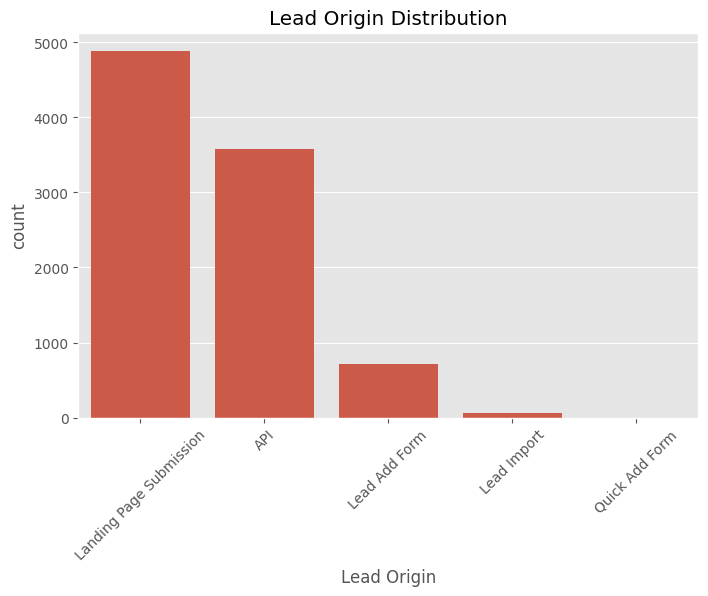

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x='Lead Origin',
              order=df['Lead Origin'].value_counts().index)

plt.xticks(rotation=45)
plt.title("Lead Origin Distribution")
plt.show()

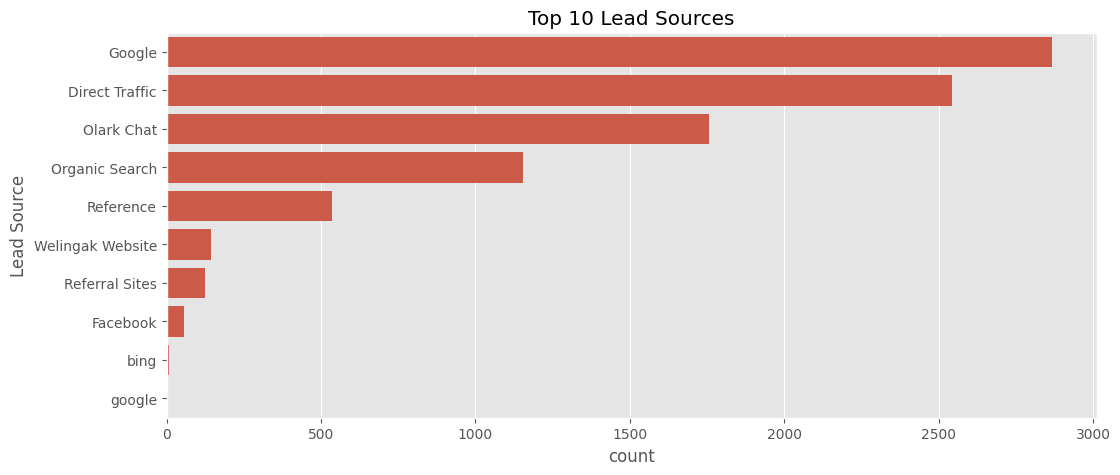

In [16]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    y='Lead Source',
    order=df['Lead Source'].value_counts().head(10).index
)

plt.title("Top 10 Lead Sources")
plt.show()

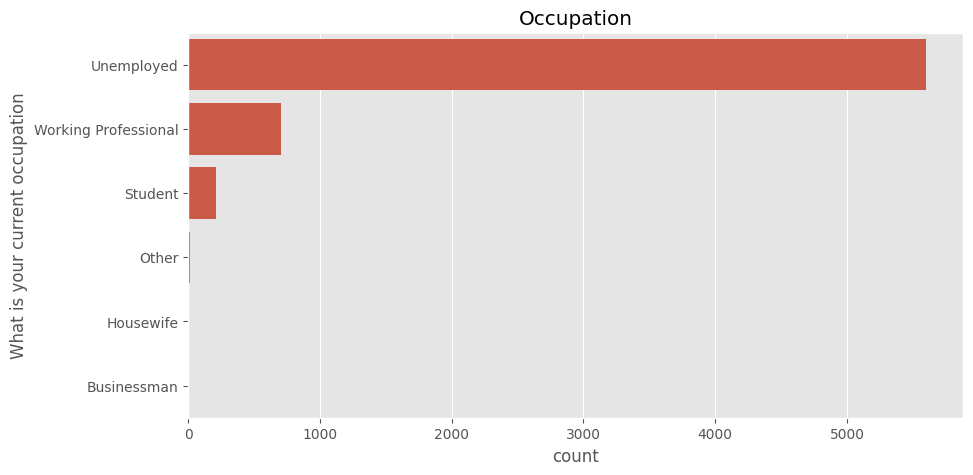

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='What is your current occupation',
    order=df['What is your current occupation'].value_counts().index
)

plt.title("Occupation")
plt.show()

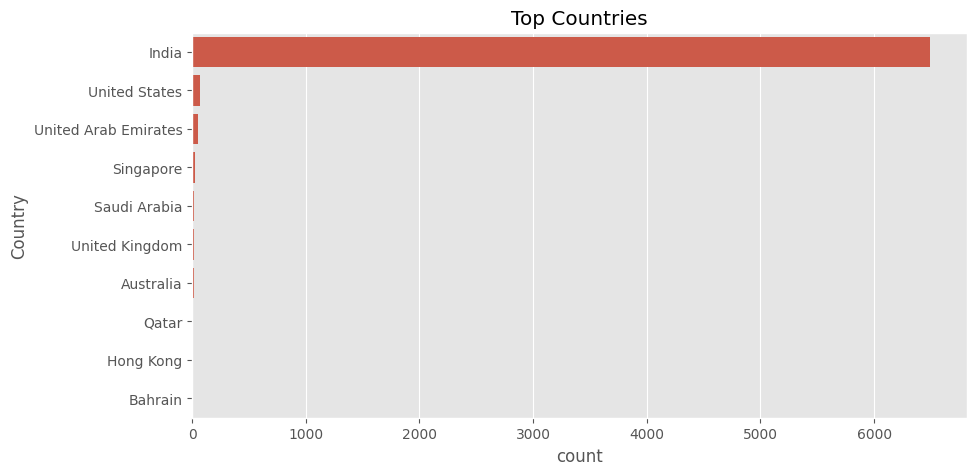

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='Country',
    order=df['Country'].value_counts().head(10).index
)

plt.title("Top Countries")
plt.show()

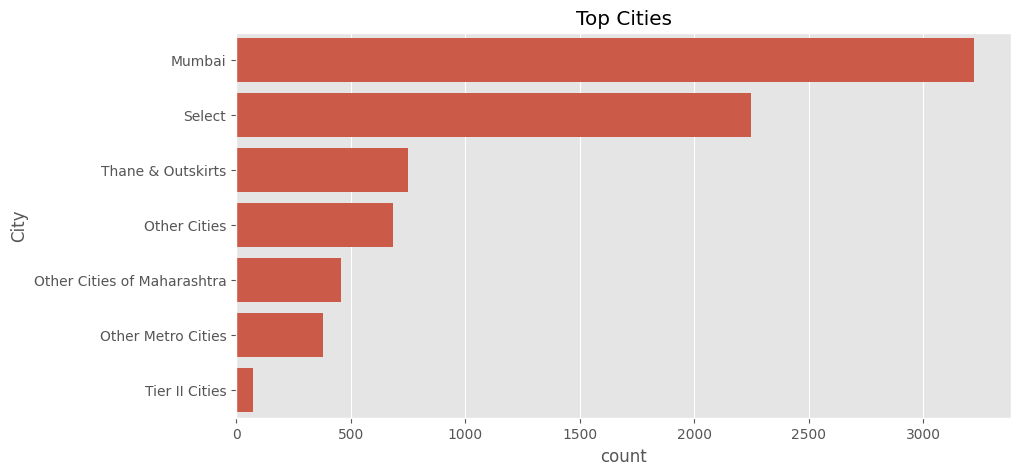

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='City',
    order=df['City'].value_counts().head(10).index
)

plt.title("Top Cities")
plt.show()

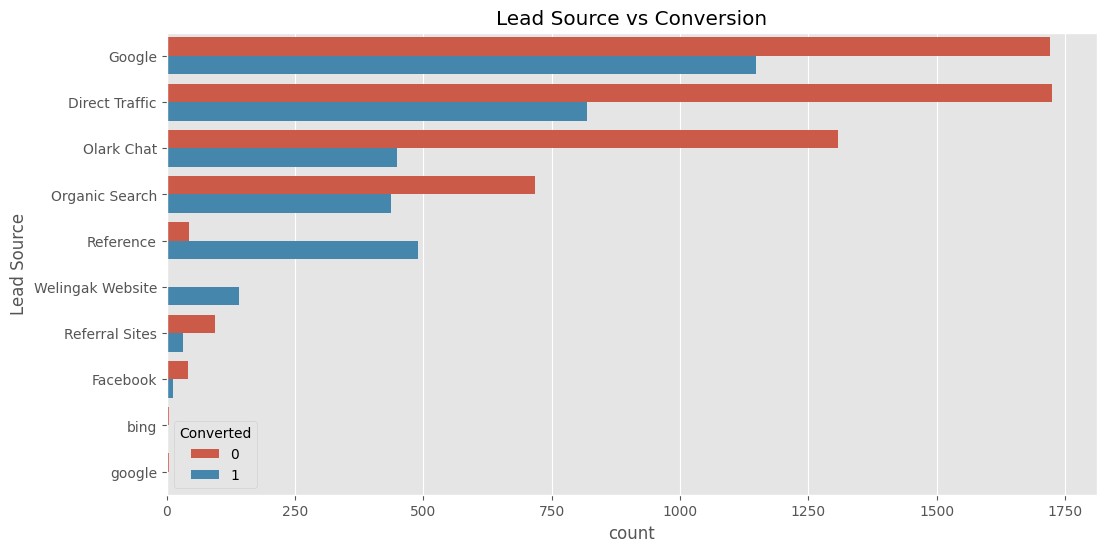

In [20]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='Lead Source',
    hue='Converted',
    order=df['Lead Source'].value_counts().head(10).index
)

plt.title("Lead Source vs Conversion")
plt.show()

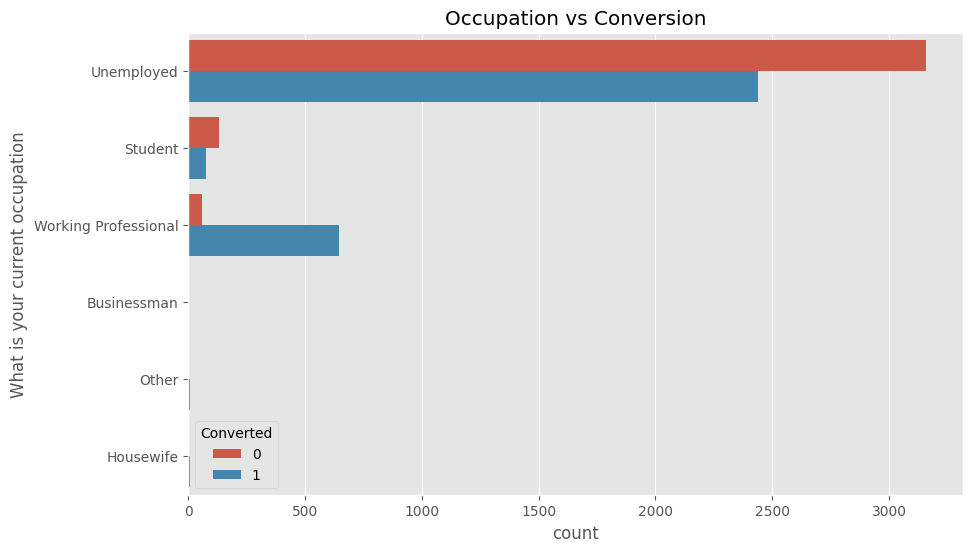

In [21]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y='What is your current occupation',
    hue='Converted'
)

plt.title("Occupation vs Conversion")
plt.show()

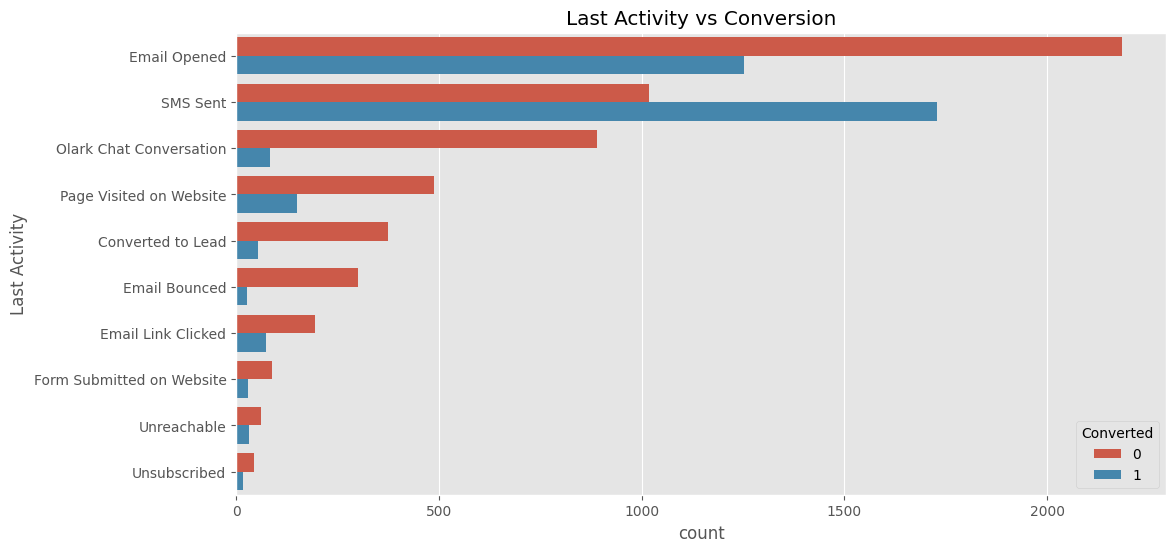

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='Last Activity',
    hue='Converted',
    order=df['Last Activity'].value_counts().head(10).index
)

plt.title("Last Activity vs Conversion")
plt.show()